# Open-Meteo Data Preprocessing

Preprocesses `all_stations_openmeteo_hourly.csv` produced by `openmeteo_data_crawling.ipynb`.

Pipeline:
1. Load & explore raw data
2. Drop all-NaN columns (`visibility_m`)
3. Fill `boundary_layer_height_m` gaps (time interpolation)
4. Recompute derived features after gap-fill
5. Save cleaned hourly CSV
6. Aggregate to daily (mean / std / min / max)
7. Add time features
8. Train / validation / test split (70 / 15 / 15, chronological)
9. Save all outputs to `data/interim/openmeteo/`

## 1. Imports & Configuration

In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ── Paths ──────────────────────────────────────────────────────────────────────
PROJECT_ROOT = Path("D:/Bussiness_plan/Multimodal_PM25")
INPUT_CSV    = PROJECT_ROOT / "data/raw/DataAOD/Hanoi/all_stations_openmeteo_hourly.csv"
OUTPUT_DIR   = PROJECT_ROOT / "data/interim/openmeteo"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Settings ───────────────────────────────────────────────────────────────────
TRAIN_FRAC = 0.70
VAL_FRAC   = 0.15

# Max consecutive hours to interpolate for BLH gaps
BLH_INTERP_LIMIT = 6

# Numeric bounds for sanity checks
BOUNDS = {
    "temperature_2m_C":       (-20,  60),
    "relative_humidity_pct":  (  0, 100),
    "dew_point_2m_C":         (-30,  40),
    "wind_speed_10m_kmh":     (  0, 250),
    "wind_gusts_10m_kmh":     (  0, 350),
    "pressure_msl_hPa":       (870, 1080),
    "surface_pressure_hPa":   (870, 1080),
    "precipitation_mm":       (  0,  300),
    "rain_mm":                (  0,  300),
    "cloud_cover_pct":        (  0,  100),
    "boundary_layer_height_m":(  0, 6000),
}

WEATHER_COLS = [
    "temperature_2m_C", "relative_humidity_pct", "dew_point_2m_C",
    "wind_speed_10m_kmh", "wind_direction_deg", "wind_gusts_10m_kmh",
    "wind_u_10m", "wind_v_10m",
    "pressure_msl_hPa", "surface_pressure_hPa",
    "precipitation_mm", "rain_mm", "cloud_cover_pct",
    "boundary_layer_height_m",
    "temp_x_rh", "wind_x_rain",
]

print(f"Input : {INPUT_CSV}")
print(f"Output: {OUTPUT_DIR}")


Input : D:\Bussiness_plan\Multimodal_PM25\data\raw\DataAOD\Hanoi\all_stations_openmeteo_hourly.csv
Output: D:\Bussiness_plan\Multimodal_PM25\data\interim\openmeteo


## 2. Load & Explore

In [ ]:
df_raw = pd.read_csv(INPUT_CSV, encoding="utf-8-sig")
df_raw["datetime_utc"] = pd.to_datetime(df_raw["datetime_utc"], utc=True, errors="coerce")
df_raw = df_raw.dropna(subset=["datetime_utc"]).reset_index(drop=True)

print(f"Shape  : {df_raw.shape}")
print(f"Range  : {df_raw['datetime_utc'].min()}  ->  {df_raw['datetime_utc'].max()}")
print(f"Stations: {df_raw['location_id'].nunique()}")
display(df_raw.groupby('location_id').agg(
    name  =('location_name', 'first'),
    rows  =('datetime_utc',  'count'),
    start =('datetime_utc',  'min'),
    end   =('datetime_utc',  'max'),
))


Shape  : (120672, 22)
Range  : 2024-01-29 00:00:00+00:00  ->  2026-05-15 23:00:00+00:00
Stations: 6


,name,rows,start,end
location_id,,,,
2161292,"Số 46, phố Lưu Quang Vũ",20112,2024-01-29 00:00:00+00:00,2026-05-15 23:00:00+00:00
2161306,Minh Khai - Bắc Từ Liêm,20112,2024-01-29 00:00:00+00:00,2026-05-15 23:00:00+00:00
4946811,556 Nguyễn Văn Cừ,20112,2024-01-29 00:00:00+00:00,2026-05-15 23:00:00+00:00
4946812,Công viên Nhân Chính - Khuất Duy Tiến,20112,2024-01-29 00:00:00+00:00,2026-05-15 23:00:00+00:00
4946813,Số 1 đường Giải Phóng - phường Bạch Mai - ĐHBK,20112,2024-01-29 00:00:00+00:00,2026-05-15 23:00:00+00:00
6123215,OceanPark,20112,2024-01-29 00:00:00+00:00,2026-05-15 23:00:00+00:00


In [ ]:
# Missing value summary
miss = df_raw.isnull().sum()
miss_pct = (df_raw.isnull().mean() * 100).round(2)
miss_df = pd.DataFrame({'missing_count': miss, 'missing_pct': miss_pct})
miss_df = miss_df[miss_df['missing_count'] > 0]
if miss_df.empty:
    print("No missing values.")
else:
    print("Columns with missing values:")
    display(miss_df)


Columns with missing values:


,missing_count,missing_pct
boundary_layer_height_m,22176,18.38
visibility_m,120672,100.00


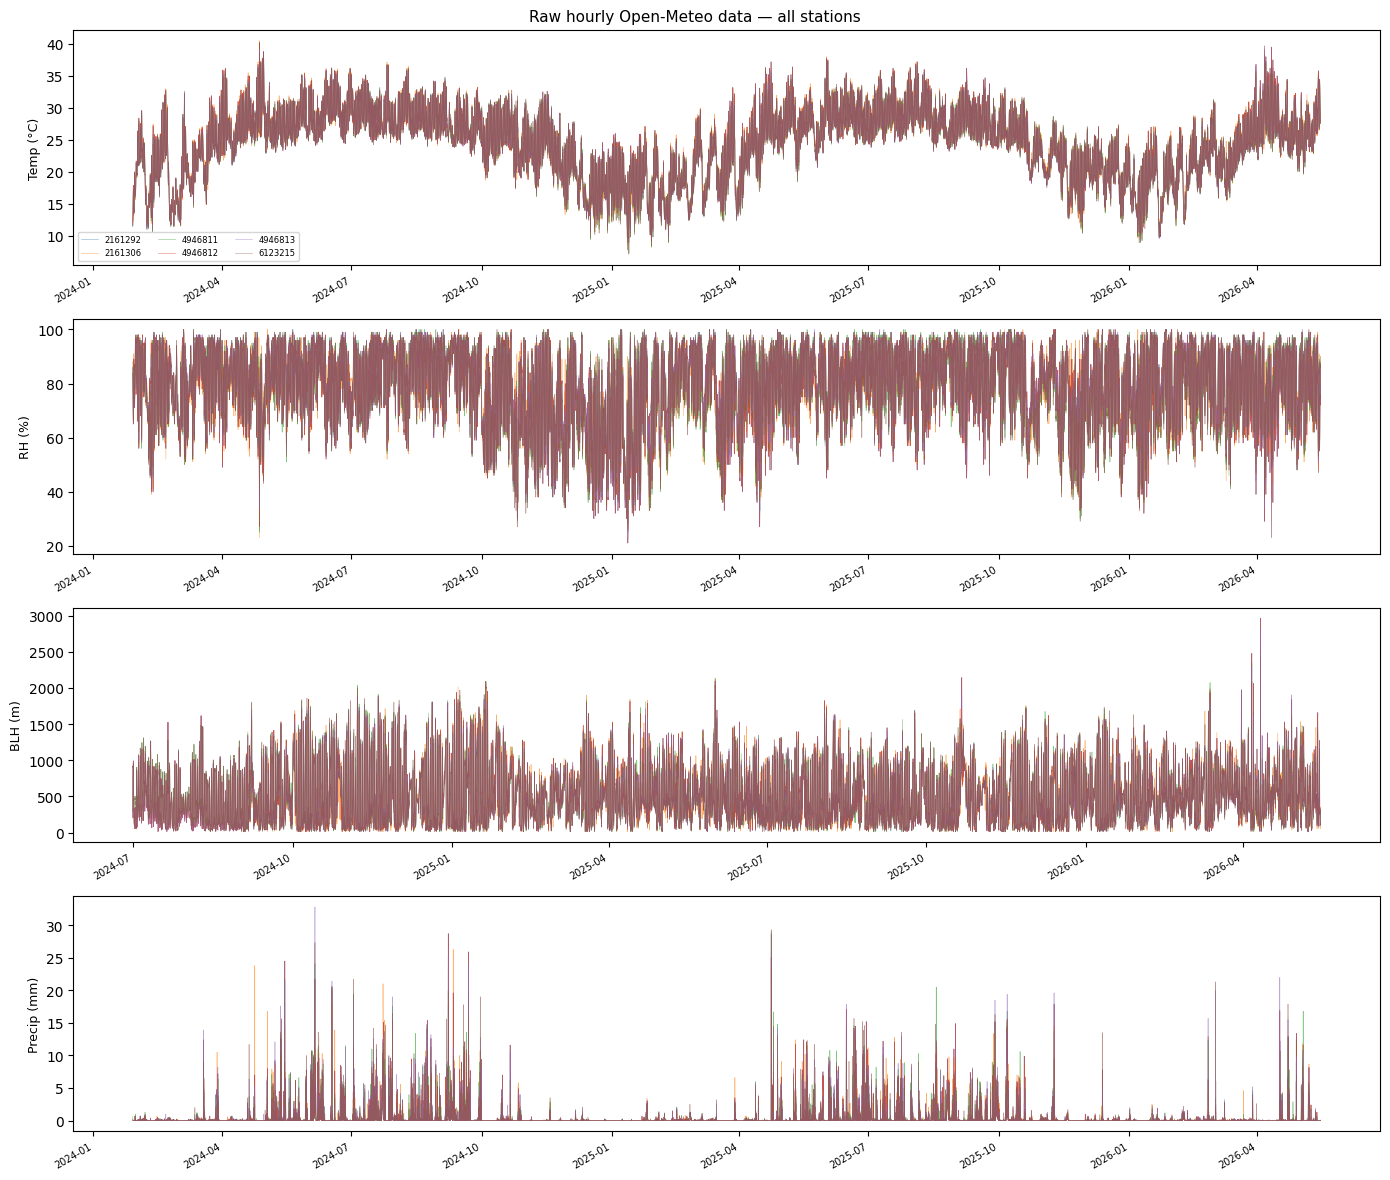

In [ ]:
# Quick overview plot — 4 key weather vars for all stations
OVERVIEW_VARS = [
    ('temperature_2m_C',       'Temp (°C)'),
    ('relative_humidity_pct',  'RH (%)'),
    ('boundary_layer_height_m','BLH (m)'),
    ('precipitation_mm',       'Precip (mm)'),
]
n_stations = df_raw['location_id'].nunique()
fig, axes = plt.subplots(len(OVERVIEW_VARS), 1, figsize=(14, 3*len(OVERVIEW_VARS)), sharex=False)
for ax, (col, label) in zip(axes, OVERVIEW_VARS):
    for loc_id, grp in df_raw.groupby('location_id'):
        grp = grp.sort_values('datetime_utc')
        ax.plot(grp['datetime_utc'], grp[col], lw=0.4, alpha=0.6, label=str(loc_id))
    ax.set_ylabel(label, fontsize=9)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right', fontsize=7)
axes[0].legend(fontsize=6, ncol=3)
plt.suptitle('Raw hourly Open-Meteo data — all stations', fontsize=11)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'raw_overview.png', dpi=120, bbox_inches='tight')
plt.show()


## 3. Clean: Drop All-NaN Columns & Clip Outliers

In [ ]:
df = df_raw.copy()

# Drop columns that are entirely NaN
all_nan_cols = [c for c in df.columns if df[c].isna().all()]
if all_nan_cols:
    print(f"Dropping all-NaN columns: {all_nan_cols}")
    df = df.drop(columns=all_nan_cols)
else:
    print("No all-NaN columns.")

# Clip each variable to valid physical range
for col, (lo, hi) in BOUNDS.items():
    if col not in df.columns:
        continue
    mask = df[col].notna() & ((df[col] < lo) | (df[col] > hi))
    if mask.any():
        print(f"  {col}: clipping {mask.sum()} out-of-range values")
    df.loc[mask, col] = np.nan

print(f"Shape after clean: {df.shape}")


Dropping all-NaN columns: ['visibility_m']
Shape after clean: (120672, 21)


## 4. Fill `boundary_layer_height_m` Gaps

`boundary_layer_height_m` is ~18% missing. We use time-based interpolation within each
station, then fall back to the station hourly median for any remaining gaps.

In [ ]:
parts = []
for loc_id, grp in df.groupby('location_id', sort=False):
    grp = grp.sort_values('datetime_utc').set_index('datetime_utc')

    # Full hourly reindex to catch any timestamp gaps
    full_idx = pd.date_range(grp.index.min(), grp.index.max(), freq='h', tz='UTC')
    grp = grp.reindex(full_idx)
    grp.index.name = 'datetime_utc'

    # Forward-fill metadata
    for mc in ['location_id', 'location_name', 'latitude', 'longitude']:
        if mc in grp.columns:
            grp[mc] = grp[mc].ffill().bfill()

    # Track which BLH values were missing
    grp['blh_was_missing'] = grp['boundary_layer_height_m'].isna().astype('int8')

    # Time interpolation (short gaps)
    grp['boundary_layer_height_m'] = grp['boundary_layer_height_m'].interpolate(
        method='time', limit=BLH_INTERP_LIMIT, limit_direction='both'
    )

    # Fallback: fill remaining NaN with hourly-of-day median from training data
    if grp['boundary_layer_height_m'].isna().any():
        grp['_hour'] = grp.index.hour
        hourly_med = grp.groupby('_hour')['boundary_layer_height_m'].transform('median')
        grp['boundary_layer_height_m'] = grp['boundary_layer_height_m'].fillna(hourly_med)
        grp = grp.drop(columns=['_hour'])

    parts.append(grp.reset_index())

df_hourly = pd.concat(parts, ignore_index=True)
df_hourly['location_id'] = df_hourly['location_id'].astype('int64')

still_missing = df_hourly['boundary_layer_height_m'].isna().sum()
print(f"BLH still missing after fill: {still_missing}")
print(f"Hourly shape: {df_hourly.shape}")


BLH still missing after fill: 0
Hourly shape: (120672, 22)


## 5. Recompute Derived Features

In [ ]:
# Recompute wind components and interactions after gap-fill
theta = np.deg2rad(df_hourly['wind_direction_deg'])
df_hourly['wind_u_10m']  = -df_hourly['wind_speed_10m_kmh'] * np.sin(theta)
df_hourly['wind_v_10m']  = -df_hourly['wind_speed_10m_kmh'] * np.cos(theta)
df_hourly['temp_x_rh']   =  df_hourly['temperature_2m_C']   * df_hourly['relative_humidity_pct']
df_hourly['wind_x_rain'] =  df_hourly['wind_speed_10m_kmh'] * df_hourly['rain_mm']
print("Derived features recomputed.")
display(df_hourly[['datetime_utc','location_id','wind_u_10m','wind_v_10m',
                    'temp_x_rh','wind_x_rain','boundary_layer_height_m']].head(4))


Derived features recomputed.


,datetime_utc,location_id,wind_u_10m,wind_v_10m,temp_x_rh,wind_x_rain,boundary_layer_height_m
0,2024-01-29 00:00:00+00:00,2161292,2.472136e+00,-7.608452,974.4,0.8,225.0
1,2024-01-29 01:00:00+00:00,2161292,-2.887830e+00,-6.486173,992.2,0.0,335.0
2,2024-01-29 02:00:00+00:00,2161292,1.861463e-15,-7.600000,1021.8,0.0,515.0
3,2024-01-29 03:00:00+00:00,2161292,1.763491e-15,-7.200000,1053.0,0.0,670.0


## 6. Save Cleaned Hourly CSV

In [ ]:
# Final column order
META_COLS = ['datetime_utc','location_id','location_name','latitude','longitude']
FEATURE_COLS = [
    "temperature_2m_C","relative_humidity_pct","dew_point_2m_C",
    "wind_speed_10m_kmh","wind_direction_deg","wind_gusts_10m_kmh",
    "wind_u_10m","wind_v_10m",
    "pressure_msl_hPa","surface_pressure_hPa",
    "precipitation_mm","rain_mm","cloud_cover_pct",
    "boundary_layer_height_m","blh_was_missing",
    "temp_x_rh","wind_x_rain",
]
FEATURE_COLS = [c for c in FEATURE_COLS if c in df_hourly.columns]
df_hourly = df_hourly[META_COLS + FEATURE_COLS].sort_values(
    ['location_id','datetime_utc']).reset_index(drop=True)

out_hourly = OUTPUT_DIR / 'all_stations_openmeteo_hourly_clean.csv'
df_hourly.to_csv(out_hourly, index=False, encoding='utf-8-sig')
print(f"Saved hourly: {out_hourly.name}  shape={df_hourly.shape}")
display(df_hourly.head(3))


Saved hourly: all_stations_openmeteo_hourly_clean.csv  shape=(120672, 22)


,datetime_utc,location_id,location_name,latitude,longitude,temperature_2m_C,relative_humidity_pct,dew_point_2m_C,wind_speed_10m_kmh,wind_direction_deg,...,wind_v_10m,pressure_msl_hPa,surface_pressure_hPa,precipitation_mm,rain_mm,cloud_cover_pct,boundary_layer_height_m,blh_was_missing,temp_x_rh,wind_x_rain
0,2024-01-29 00:00:00+00:00,2161292,"Số 46, phố Lưu Quang Vũ",21.0152,105.7999,11.6,84.0,9.1,8.0,342,...,-7.608452,1024.2,1022.4,0.1,0.1,100.0,225.0,1,974.4,0.8
1,2024-01-29 01:00:00+00:00,2161292,"Số 46, phố Lưu Quang Vũ",21.0152,105.7999,12.1,82.0,9.1,7.1,24,...,-6.486173,1025.0,1023.2,0.0,0.0,100.0,335.0,1,992.2,0.0
2,2024-01-29 02:00:00+00:00,2161292,"Số 46, phố Lưu Quang Vũ",21.0152,105.7999,13.1,78.0,9.4,7.6,360,...,-7.600000,1025.6,1023.8,0.0,0.0,100.0,515.0,1,1021.8,0.0


## 7. Aggregate to Daily

In [ ]:
df_hourly['date'] = df_hourly['datetime_utc'].dt.normalize()

AGG = {
    'temperature_2m_C':      ['mean','std','min','max'],
    'relative_humidity_pct': ['mean','std','min','max'],
    'dew_point_2m_C':        ['mean'],
    'wind_speed_10m_kmh':    ['mean','max'],
    'wind_gusts_10m_kmh':    ['max'],
    'wind_u_10m':            ['mean'],
    'wind_v_10m':            ['mean'],
    'pressure_msl_hPa':      ['mean'],
    'surface_pressure_hPa':  ['mean'],
    'precipitation_mm':      ['sum'],
    'rain_mm':               ['sum'],
    'cloud_cover_pct':       ['mean'],
    'boundary_layer_height_m':['mean','min','max'],
    'temp_x_rh':             ['mean'],
    'wind_x_rain':           ['sum'],
    'blh_was_missing':       ['sum'],
}
# Keep only columns that exist
AGG = {k: v for k, v in AGG.items() if k in df_hourly.columns}

df_daily = (
    df_hourly
    .groupby(['location_id','location_name','latitude','longitude','date'])
    .agg(AGG)
    .reset_index()
)

# Flatten MultiIndex columns
df_daily.columns = [
    '_'.join(filter(None, map(str, c))).strip('_')
    if isinstance(c, tuple) else c
    for c in df_daily.columns
]

# Rename for clarity
RENAME = {
    'precipitation_mm_sum':         'precip_daily_mm',
    'rain_mm_sum':                  'rain_daily_mm',
    'wind_x_rain_sum':              'wind_x_rain_daily',
    'blh_was_missing_sum':          'blh_missing_hours',
    'boundary_layer_height_m_mean': 'blh_mean_m',
    'boundary_layer_height_m_min':  'blh_min_m',
    'boundary_layer_height_m_max':  'blh_max_m',
    'wind_gusts_10m_kmh_max':       'wind_gusts_max_kmh',
    'wind_speed_10m_kmh_mean':      'wind_speed_mean_kmh',
    'wind_speed_10m_kmh_max':       'wind_speed_max_kmh',
    'cloud_cover_pct_mean':         'cloud_cover_mean_pct',
    'pressure_msl_hPa_mean':        'pressure_msl_mean_hPa',
    'surface_pressure_hPa_mean':    'surface_pressure_mean_hPa',
    'dew_point_2m_C_mean':          'dew_point_mean_C',
    'wind_u_10m_mean':              'wind_u_mean',
    'wind_v_10m_mean':              'wind_v_mean',
    'temp_x_rh_mean':               'temp_x_rh_mean',
}
df_daily = df_daily.rename(columns={k: v for k, v in RENAME.items() if k in df_daily.columns})
df_daily['date'] = pd.to_datetime(df_daily['date'])
df_daily = df_daily.sort_values(['location_id','date']).reset_index(drop=True)

print(f"Daily shape: {df_daily.shape}")
display(df_daily.head(3))


Daily shape: (5028, 30)


,location_id,location_name,latitude,longitude,date,temperature_2m_C_mean,temperature_2m_C_std,temperature_2m_C_min,temperature_2m_C_max,relative_humidity_pct_mean,...,surface_pressure_mean_hPa,precip_daily_mm,rain_daily_mm,cloud_cover_mean_pct,blh_mean_m,blh_min_m,blh_max_m,temp_x_rh_mean,wind_x_rain_daily,blh_missing_hours
0,2161292,"Số 46, phố Lưu Quang Vũ",21.0152,105.7999,2024-01-29 00:00:00+00:00,14.454167,1.740310,11.6,17.9,79.208333,...,1019.304167,0.1,0.1,99.958333,436.354167,175.0,965.0,1132.937500,0.80,24
1,2161292,"Số 46, phố Lưu Quang Vũ",21.0152,105.7999,2024-01-30 00:00:00+00:00,17.229167,1.680186,13.8,20.0,84.791667,...,1016.341667,0.8,0.8,99.708333,436.354167,175.0,965.0,1453.512500,4.86,24
2,2161292,"Số 46, phố Lưu Quang Vũ",21.0152,105.7999,2024-01-31 00:00:00+00:00,19.429167,1.359181,16.4,21.7,89.625000,...,1014.325000,0.1,0.1,100.000000,436.354167,175.0,965.0,1735.766667,0.46,24


## 8. Time Features & Train / Validation / Test Split

In [ ]:
# Time features
df_daily['day_of_week'] = df_daily['date'].dt.dayofweek
df_daily['day_of_year'] = df_daily['date'].dt.dayofyear
df_daily['month']       = df_daily['date'].dt.month
df_daily['year']        = df_daily['date'].dt.year
df_daily['is_weekend']  = df_daily['day_of_week'].isin([5, 6]).astype('int8')
df_daily['season'] = df_daily['month'].map(
    lambda m: 'winter' if m in [12,1,2]
              else 'spring' if m in [3,4,5]
              else 'summer' if m in [6,7,8]
              else 'autumn'
)

# Chronological 70/15/15 split (global date cutoffs)
all_dates = np.sort(df_daily['date'].dt.normalize().unique())
n = len(all_dates)
train_cut = all_dates[int(n * TRAIN_FRAC)]
val_cut   = all_dates[int(n * (TRAIN_FRAC + VAL_FRAC))]

df_daily['split'] = 'test'
df_daily.loc[df_daily['date'] < train_cut, 'split'] = 'train'
df_daily.loc[
    (df_daily['date'] >= train_cut) & (df_daily['date'] < val_cut),
    'split'
] = 'validation'

print(f"Train cutoff : {train_cut.date()}")
print(f"Val   cutoff : {val_cut.date()}")
display(df_daily.groupby(['location_id','split']).agg(
    rows  =('date','count'),
    start =('date','min'),
    end   =('date','max'),
))


Train cutoff : 2025-09-06
Val   cutoff : 2026-01-10


rows                     start  \
location_id split                                        
2161292     test         126 2026-01-10 00:00:00+00:00   
            train        586 2024-01-29 00:00:00+00:00   
            validation   126 2025-09-06 00:00:00+00:00   
2161306     test         126 2026-01-10 00:00:00+00:00   
            train        586 2024-01-29 00:00:00+00:00   
            validation   126 2025-09-06 00:00:00+00:00   
4946811     test         126 2026-01-10 00:00:00+00:00   
            train        586 2024-01-29 00:00:00+00:00   
            validation   126 2025-09-06 00:00:00+00:00   
4946812     test         126 2026-01-10 00:00:00+00:00   
            train        586 2024-01-29 00:00:00+00:00   
            validation   126 2025-09-06 00:00:00+00:00   
4946813     test         126 2026-01-10 00:00:00+00:00   
            train        586 2024-01-29 00:00:00+00:00   
            validation   126 2025-09-06 00:00:00+00:00   
6123215     test         126 2026-01-10 00:00:00+00:00   
            train        586 2024-01-29 00:00:00+00:00   
            validation   126 2025-09-06 00:00:00+00:00   

                                             end  
location_id split                                 
2161292     test       2026-05-15 00:00:00+00:00  
            train      2025-09-05 00:00:00+00:00  
            validation 2026-01-09 00:00:00+00:00  
2161306     test       2026-05-15 00:00:00+00:00  
            train      2025-09-05 00:00:00+00:00  
            validation 2026-01-09 00:00:00+00:00  
4946811     test       2026-05-15 00:00:00+00:00  
            train      2025-09-05 00:00:00+00:00  
            validation 2026-01-09 00:00:00+00:00  
4946812     test       2026-05-15 00:00:00+00:00  
            train      2025-09-05 00:00:00+00:00  
            validation 2026-01-09 00:00:00+00:00  
4946813     test       2026-05-15 00:00:00+00:00  
            train      2025-09-05 00:00:00+00:00  
            validation 2026-01-09 00:00:00+00:00  
6123215     test       2026-05-15 00:00:00+00:00  
            train      2025-09-05 00:00:00+00:00  
            validation 2026-01-09 00:00:00+00:00

## 9. Save Outputs

In [ ]:
# Combined daily
out_all = OUTPUT_DIR / 'all_stations_daily.csv'
df_daily.to_csv(out_all, index=False, encoding='utf-8-sig')
print(f"Saved: {out_all.name}  shape={df_daily.shape}")

# Split files
for split_name, grp in df_daily.groupby('split', sort=False):
    out = OUTPUT_DIR / f'{split_name}.csv'
    grp.to_csv(out, index=False, encoding='utf-8-sig')
    print(f"  {split_name}.csv  rows={len(grp)}")

# Per-station daily
for loc_id, grp in df_daily.groupby('location_id', sort=False):
    out = OUTPUT_DIR / f'station_{loc_id}_daily.csv'
    grp.to_csv(out, index=False, encoding='utf-8-sig')
    print(f"  station_{loc_id}_daily.csv  rows={len(grp)}")

print(f"\nAll outputs -> {OUTPUT_DIR}")


Saved: all_stations_daily.csv  shape=(5028, 37)


  train.csv  rows=3516
  validation.csv  rows=756
  test.csv  rows=756
  station_2161292_daily.csv  rows=838
  station_2161306_daily.csv  rows=838
  station_4946811_daily.csv  rows=838
  station_4946812_daily.csv  rows=838


  station_4946813_daily.csv  rows=838
  station_6123215_daily.csv  rows=838

All outputs -> D:\Bussiness_plan\Multimodal_PM25\data\interim\openmeteo


## 10. EDA — Daily Weather by Station & Split

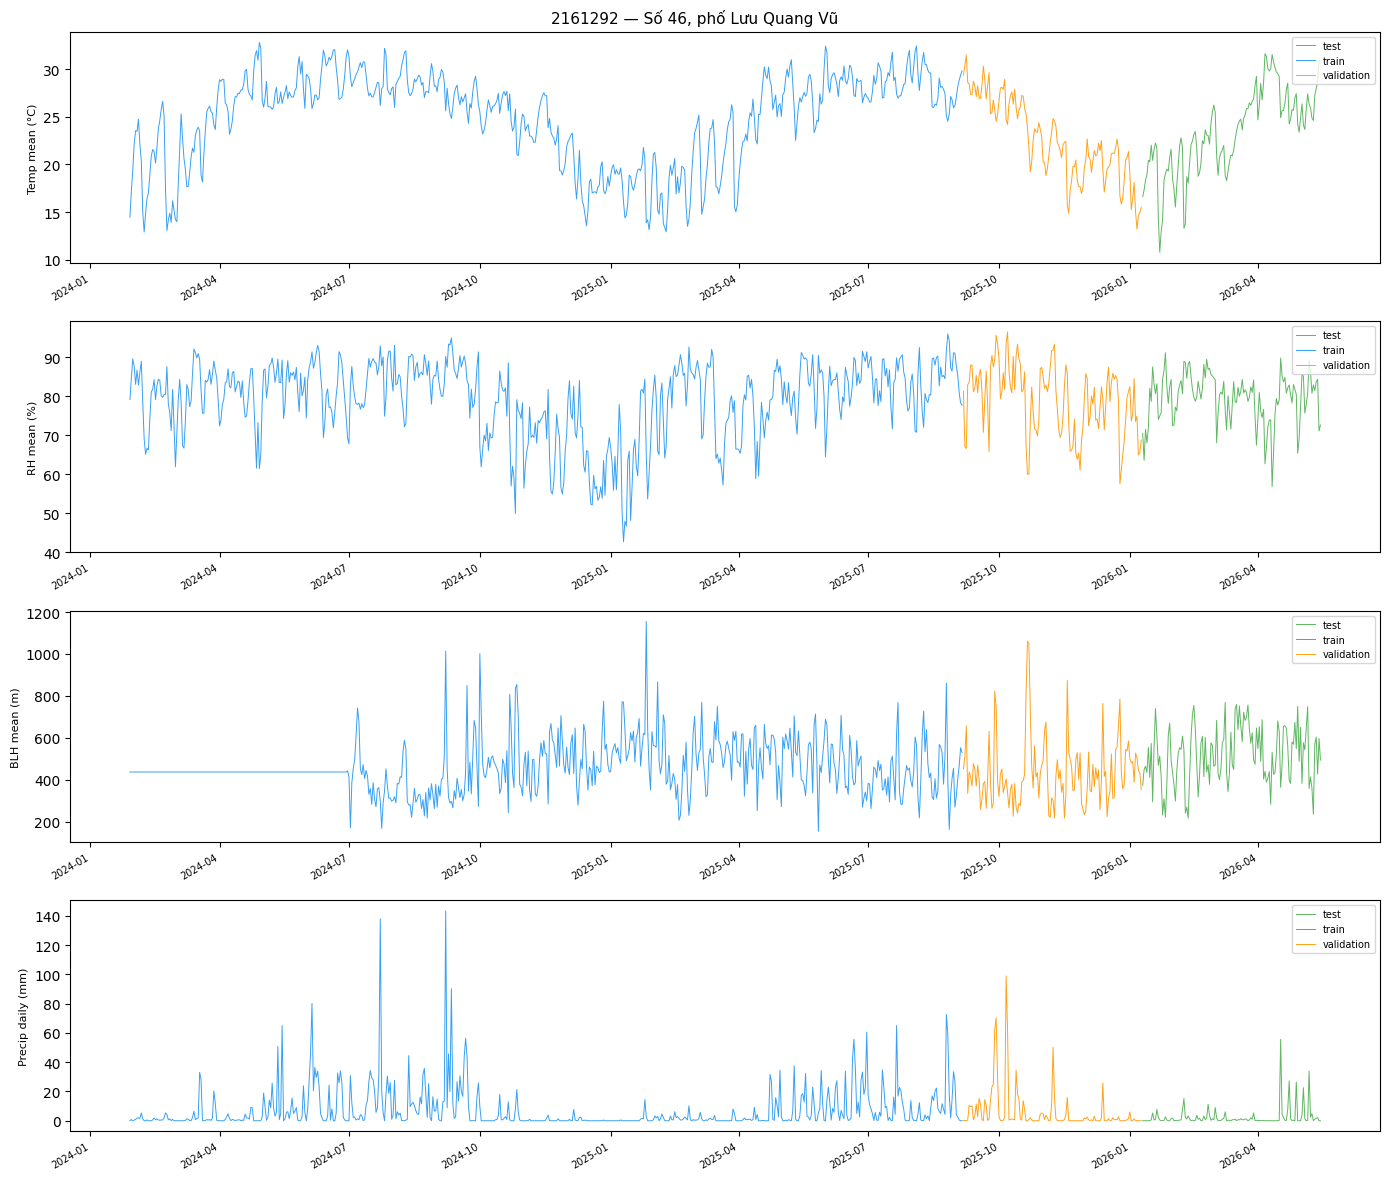

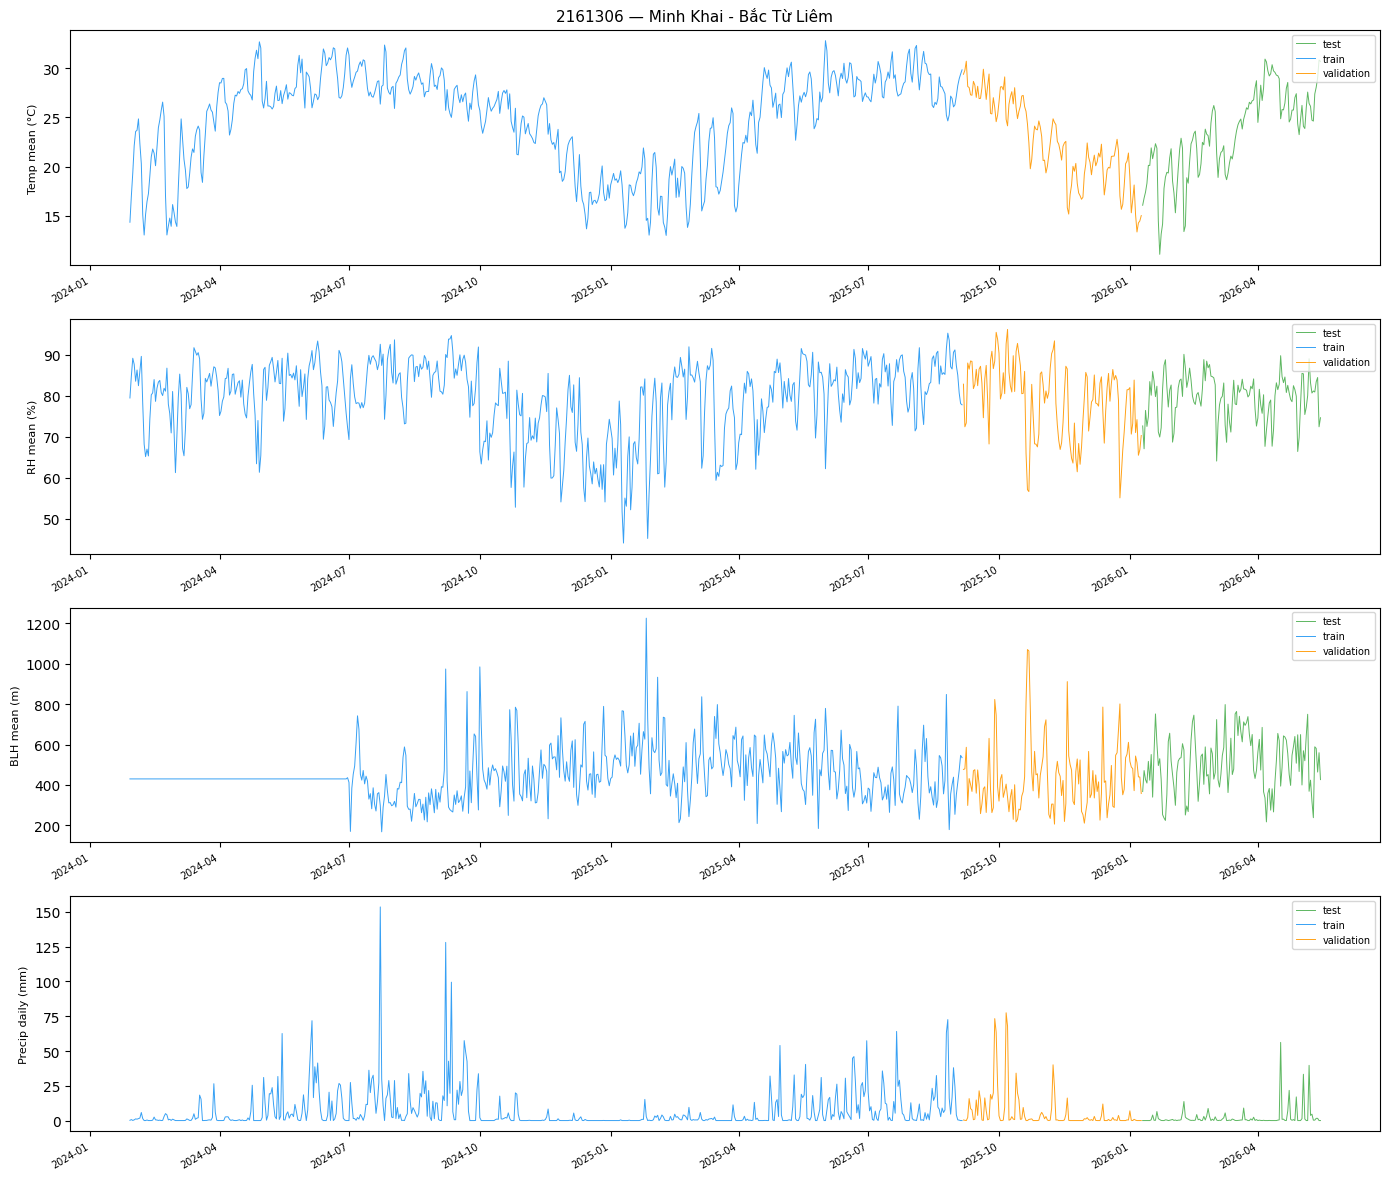

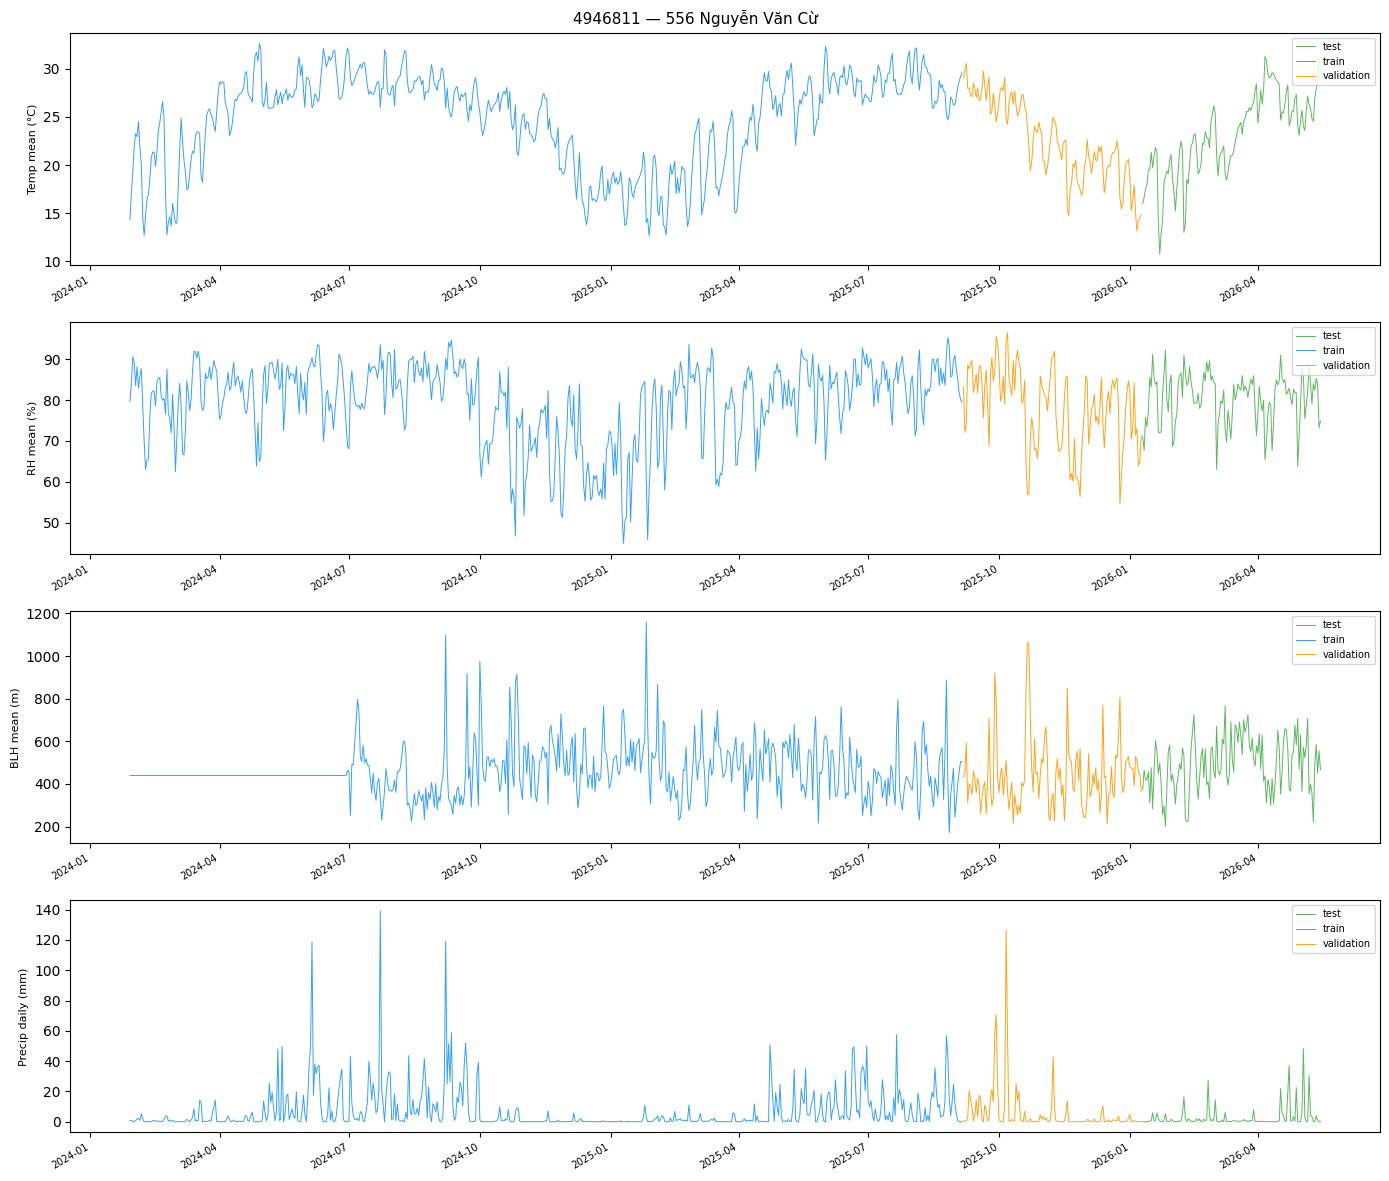

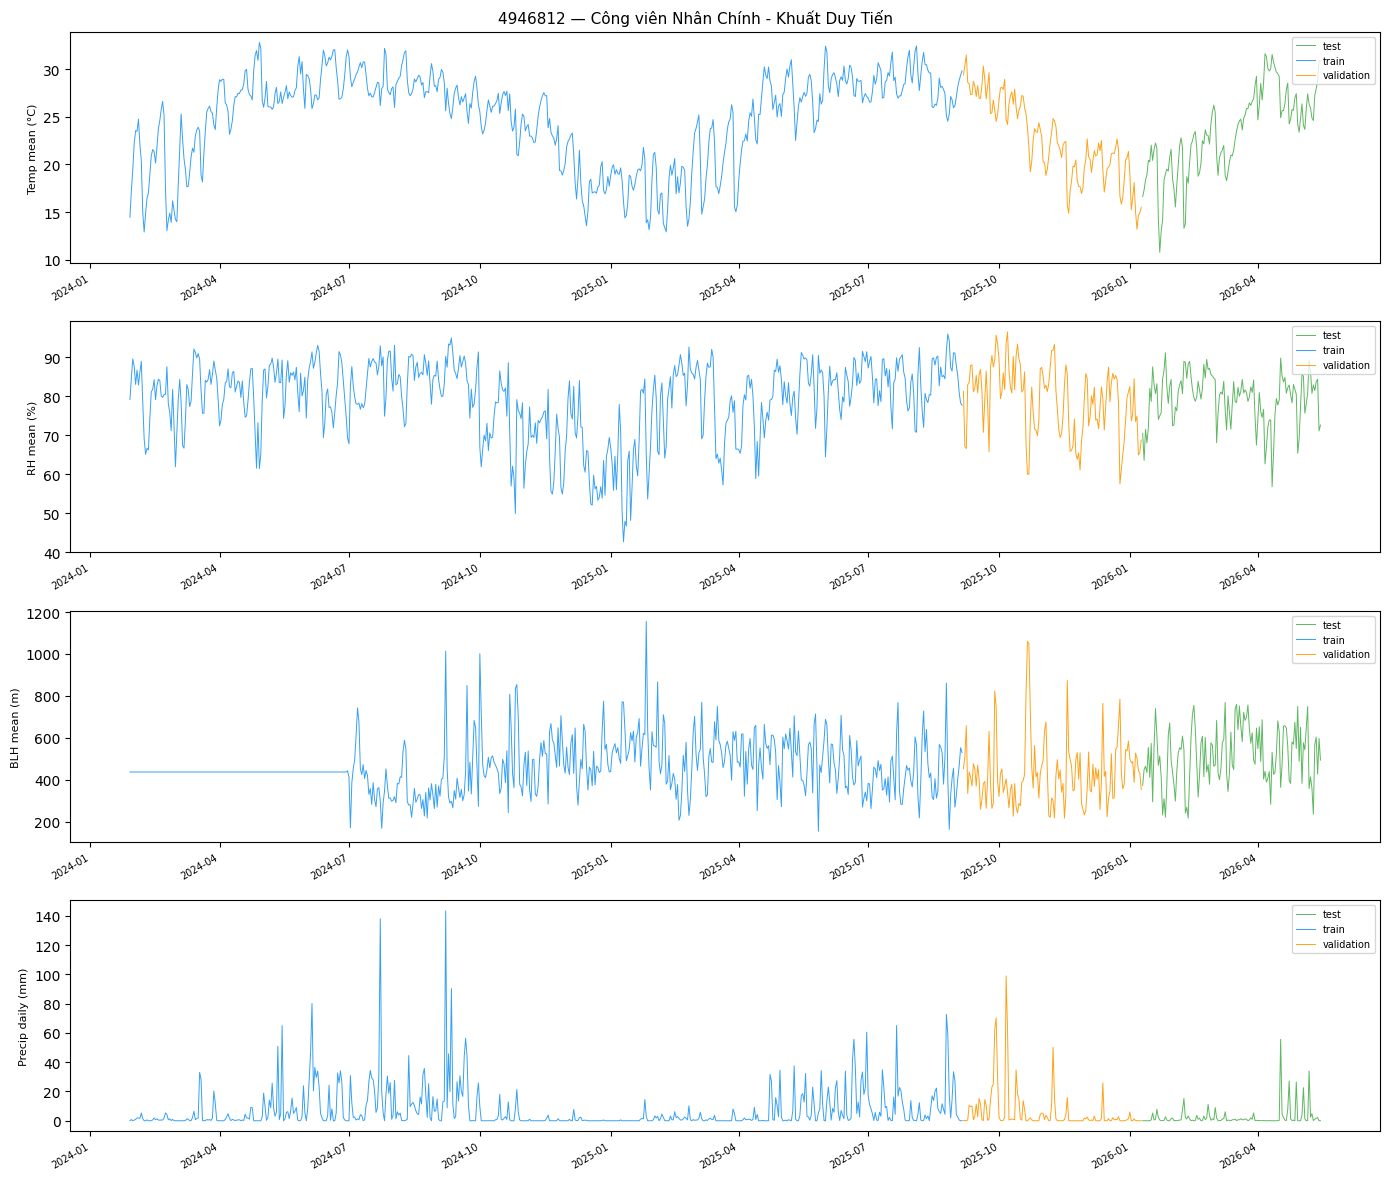

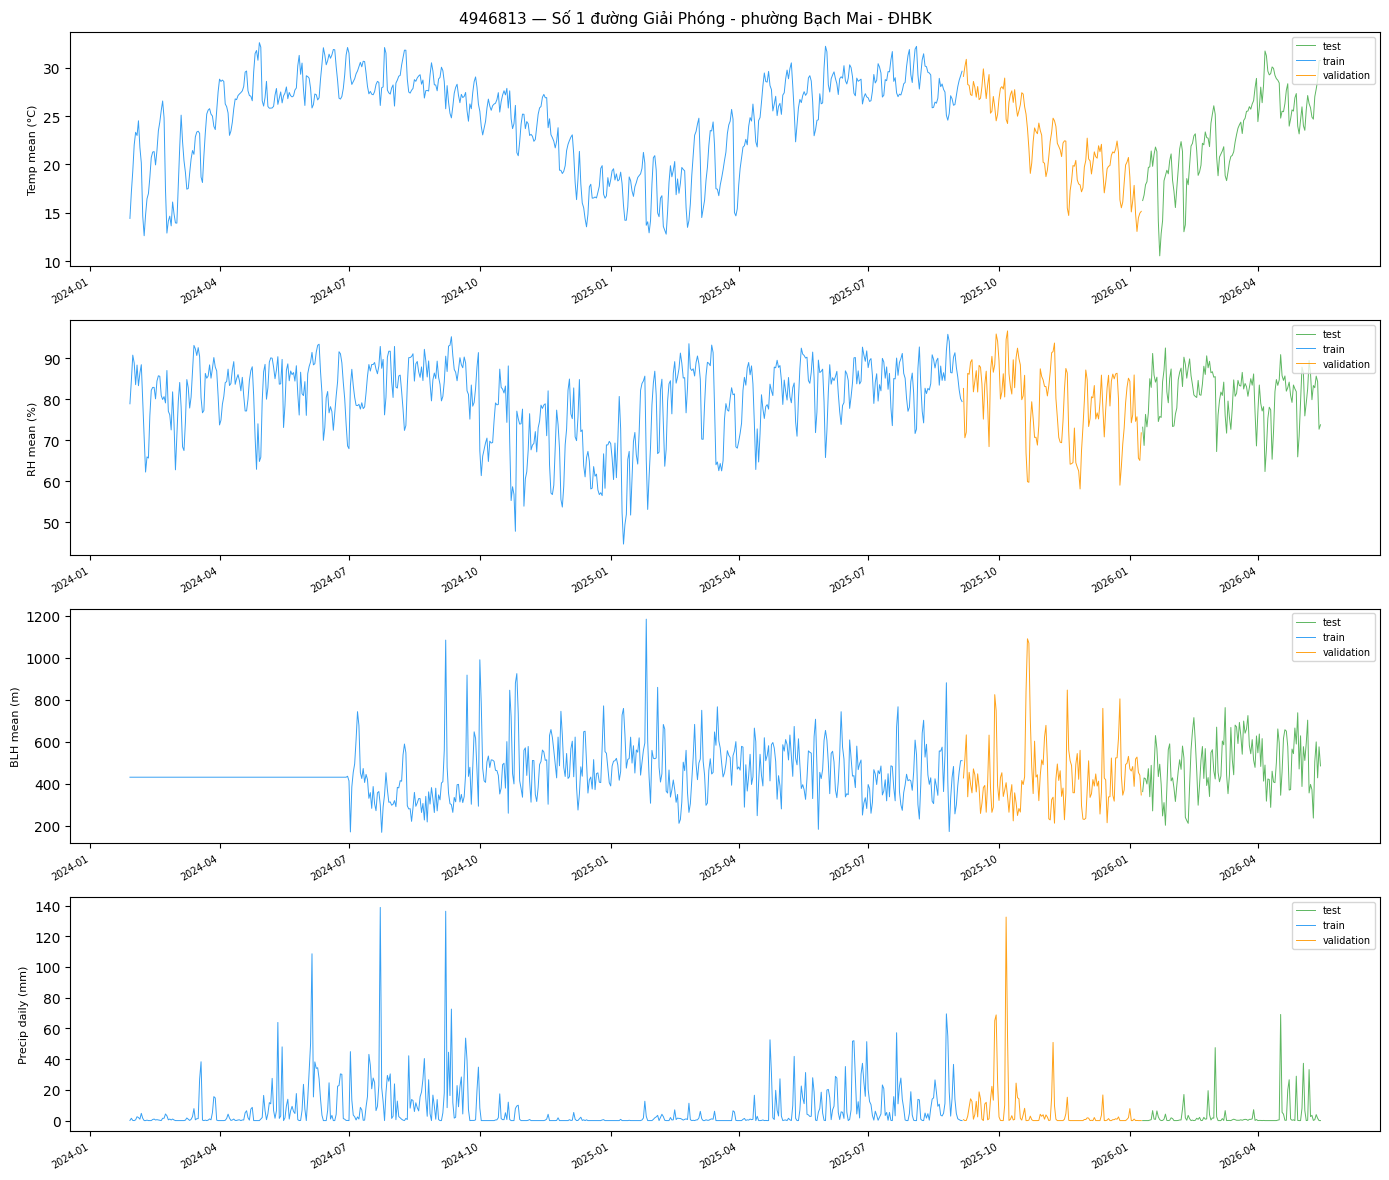

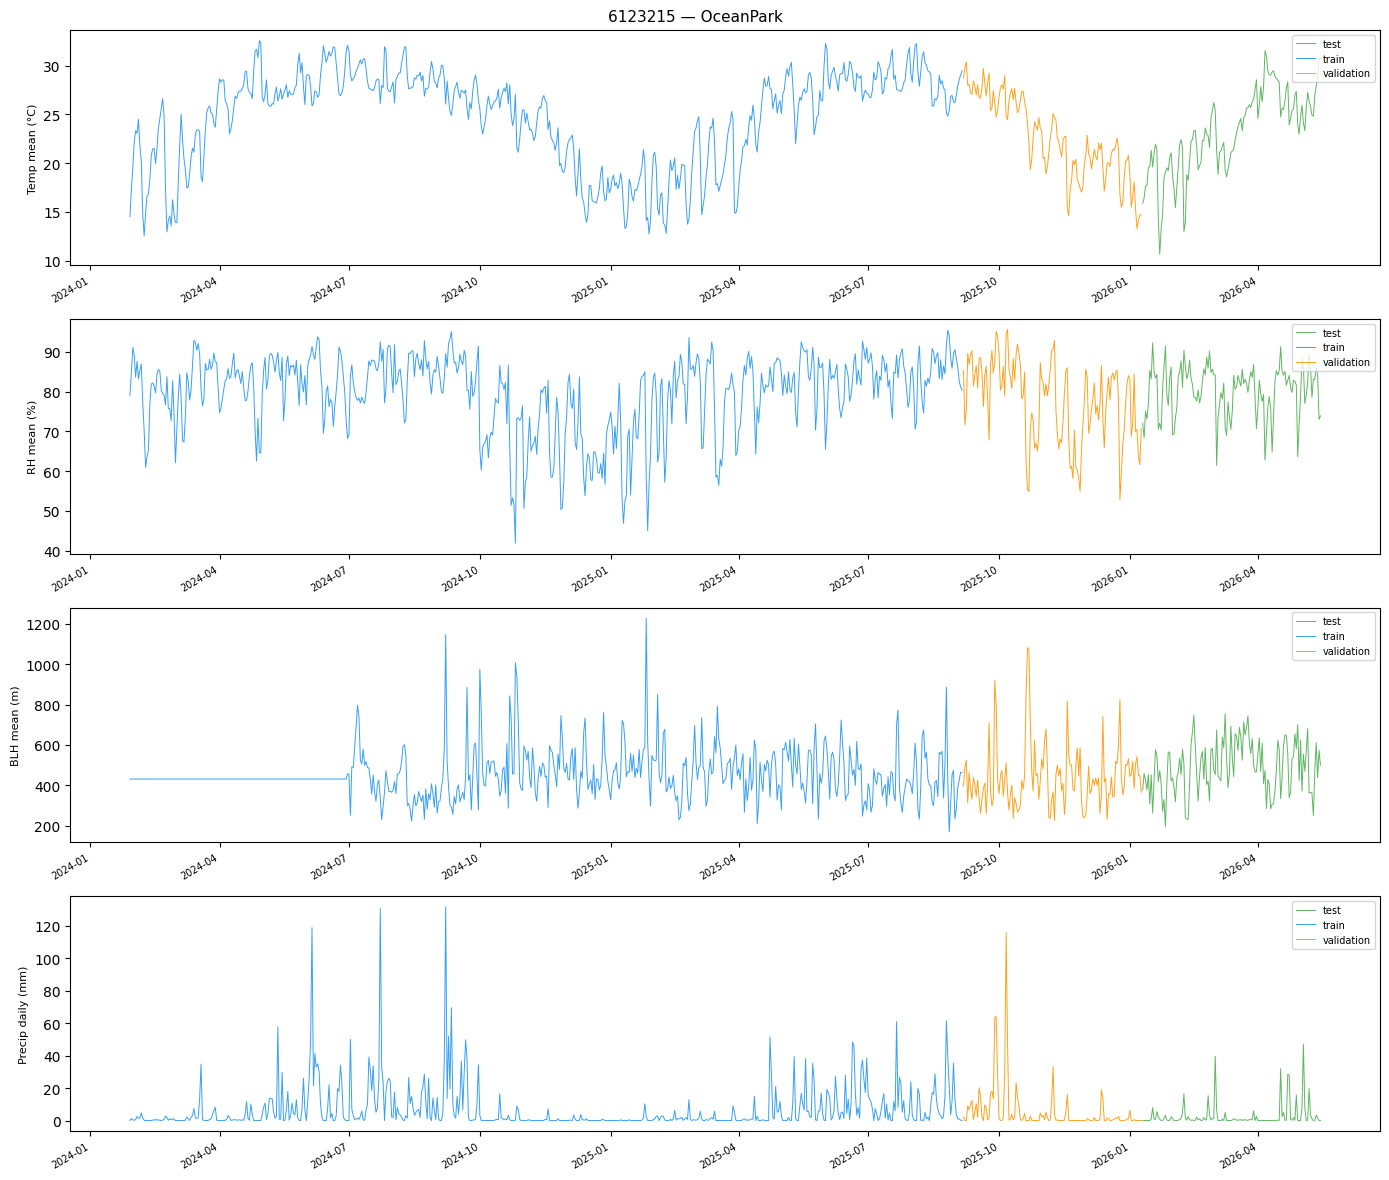

In [ ]:
SPLIT_COLORS = {'train':'#2196F3','validation':'#FF9800','test':'#4CAF50'}

PLOT_VARS = [
    ('temperature_2m_C_mean', 'Temp mean (°C)'),
    ('relative_humidity_pct_mean', 'RH mean (%)'),
    ('blh_mean_m', 'BLH mean (m)'),
    ('precip_daily_mm', 'Precip daily (mm)'),
]
# Use actual column names that exist
PLOT_VARS = [(c, lbl) for c, lbl in PLOT_VARS if c in df_daily.columns]

for loc_id, grp in df_daily.groupby('location_id'):
    loc_name = grp['location_name'].iloc[0]
    grp = grp.sort_values('date')
    fig, axes = plt.subplots(len(PLOT_VARS), 1,
                             figsize=(14, 3*len(PLOT_VARS)), sharex=False)
    if len(PLOT_VARS) == 1:
        axes = [axes]
    fig.suptitle(f'{loc_id} — {loc_name}', fontsize=11)
    for ax, (col, label) in zip(axes, PLOT_VARS):
        for spl, sgrp in grp.groupby('split'):
            ax.plot(sgrp['date'], sgrp[col],
                    color=SPLIT_COLORS.get(spl,'gray'), lw=0.7, alpha=0.9, label=spl)
        ax.set_ylabel(label, fontsize=8)
        ax.legend(loc='upper right', fontsize=7)
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right', fontsize=7)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f'station_{loc_id}_daily.png', dpi=100, bbox_inches='tight')
    plt.show()


## 11. (Optional) Merge with OpenAQ Daily

Join the weather daily features with the OpenAQ processed daily data
to produce a single modeling table with both PM2.5 and weather features.

In [ ]:
openaq_daily_path = PROJECT_ROOT / "data/interim/openaq/all_stations_daily.csv"

if openaq_daily_path.exists():
    df_aq = pd.read_csv(openaq_daily_path, encoding='utf-8-sig')
    df_aq['date'] = pd.to_datetime(df_aq['date'])

    # Weather feature columns (exclude meta + time + split cols)
    exclude = {'location_id','location_name','latitude','longitude',
               'date','split','day_of_week','day_of_year','month','year',
               'is_weekend','season'}
    weather_feat_cols = [c for c in df_daily.columns if c not in exclude]

    df_combined = df_aq.merge(
        df_daily[['location_id','date'] + weather_feat_cols],
        on=['location_id','date'],
        how='left',
    )

    out_combined = OUTPUT_DIR / 'all_stations_openaq_meteo_daily.csv'
    df_combined.to_csv(out_combined, index=False, encoding='utf-8-sig')
    print(f"Combined OpenAQ + Meteo: {out_combined.name}  shape={df_combined.shape}")
    display(df_combined.head(3))
else:
    print(f"OpenAQ daily not found at {openaq_daily_path}")
    print("Run openaq_preprocessing.ipynb first, then re-run this cell.")


Combined OpenAQ + Meteo: all_stations_openaq_meteo_daily.csv  shape=(2585, 52)


,date,location_id,location_name,latitude,longitude,pm25_mean,pm25_std,pm25_min,pm25_max,pm25_hourly_count,...,surface_pressure_mean_hPa,precip_daily_mm,rain_daily_mm,cloud_cover_mean_pct,blh_mean_m,blh_min_m,blh_max_m,temp_x_rh_mean,wind_x_rain_daily,blh_missing_hours
0,2024-01-29 00:00:00+00:00,2161292,"Số 46, phố Lưu Quang Vũ",21.0152,105.7999,49.964286,2.430993,45.92,53.02,7,...,1019.304167,0.1,0.1,99.958333,436.354167,175.0,965.0,1132.937500,0.80,24
1,2024-01-30 00:00:00+00:00,2161292,"Số 46, phố Lưu Quang Vũ",21.0152,105.7999,55.806250,10.596282,36.86,71.40,24,...,1016.341667,0.8,0.8,99.708333,436.354167,175.0,965.0,1453.512500,4.86,24
2,2024-01-31 00:00:00+00:00,2161292,"Số 46, phố Lưu Quang Vũ",21.0152,105.7999,30.300000,10.179224,13.38,47.46,24,...,1014.325000,0.1,0.1,100.000000,436.354167,175.0,965.0,1735.766667,0.46,24
